# Backtest-Overfitting — why every backtest is a 10 and every live run is a 3 📉
### How searching hard enough turns pure noise into a 'great strategy'

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_grid--search_fake_an_edge%3F: Confirmed](https://img.shields.io/badge/Does_grid--search_fake_an_edge%3F-Confirmed-8b949e?style=flat-square)

Every backtest you're ever shown looks gorgeous. Then real money goes in and the magic evaporates. This isn't bad luck — it's *arithmetic*. If you try enough strategy settings on the same data, one of them is **guaranteed** to look brilliant, even when there is nothing there. We'll prove it on a market we built to have **zero edge**, then show the two tools that catch the trap red-handed.

> 📓 **This is the plain-language layer.** Want the Deflated Sharpe Ratio formula and the PBO cross-validation? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from backtest_overfitting import data, strategy as st

ND, N_TRIALS, N_SPLITS = 1260, 1000, 10

def _have_spy():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_spy()
print("SPY cache present:", HAVE_REAL)


SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Why does every backtest look amazing? | **Because you went looking.** Try 1,000 settings on one dataset and the luckiest will post a beautiful Sharpe — *by chance*. |
| We tested it on a market with **no edge**. What happened? | The best of 1,000 rules showed an in-sample Sharpe of **0.88** — then **-0.49** out-of-sample. The 'strategy' was noise wearing a costume. |
| Can a tool catch it? | **Yes — two of them.** The *Deflated Sharpe Ratio* haircuts the Sharpe for how many things you tried (it dropped to ~0). The *Probability of Overfitting* (PBO) came out **68%** — your winner is a loser more often than a coin flip. |
| So is there anything to trade here? | **No.** This is a study about *method*, not a signal. The lesson is the product. |

> A backtest is a *hypothesis you already peeked at*. The more you peeked, the less the pretty number means — and there's a formula for exactly how much less.

## 1 · The claim

Quants Marcos López de Prado and David Bailey put it bluntly: most published backtests are **statistically meaningless**, because the researcher tried many configurations and reported only the best one — without saying how many they tried. Their 2014 paper has a title that says it all: *Pseudo-Mathematics and Financial Charlatanism*. The strong version of the claim: **with enough trials you can hit any target Sharpe on random data**, so a backtest's Sharpe — on its own — tells you almost nothing.

## 2 · So what?

This is the single most expensive mistake in quantitative investing. It's why the 'factor zoo' has hundreds of published anomalies and so few survive replication; it's why a fund's backtested Sharpe of 2 turns into a live Sharpe of 0.3; it's why your own weekend strategy looked unstoppable and then bled. If we can *measure* how much a backtest was inflated by searching, we can tell a real edge from a mirage **before** we fund it. That's the payload.

## 3 · How would we even know?

We rig the experiment so the answer is *known*:

1. **Build a market with no edge.** A pure coin-flip price path (a 'random walk'). There is, provably, no timing rule that works on it.
2. **Unleash a parameter zoo.** Grid-search 1,000 moving-average crossover rules — the bread-and-butter of retail backtesting — and keep the best one *in-sample*.
3. **Show it live.** Run that champion on data it never saw (out-of-sample).
4. **Score the trap.** The **Deflated Sharpe Ratio** asks: is the best Sharpe better than what pure luck would hand you after 1,000 tries? The **PBO** asks: how often is the in-sample winner an out-of-sample loser?

If grid-searching is honest, the champion should keep working live. Spoiler: on a tape with no edge, it can't — and the tools say so.

## 4 · The teardown — let's actually look

**First: the gorgeous backtest that is built from nothing.** Here's the in-sample equity curve of the *best* of 1,000 crossover rules on our no-edge market — and then what the very same rule does the moment it goes live.

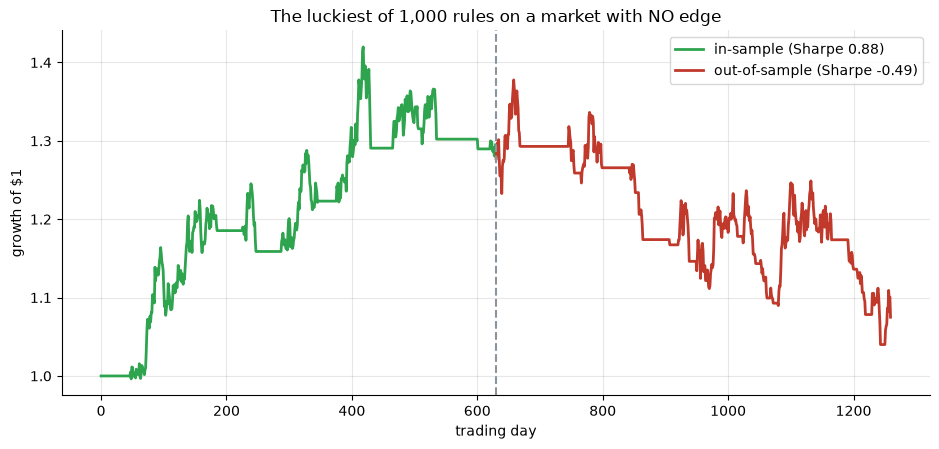

Best-of-1000 champion f2_s47: IS Sharpe 0.88 -> OOS Sharpe -0.49


In [2]:
prices, _ = data.synthetic_prices(n_days=ND, edge=0.0, seed=344)
mat = st.sweep(prices, n_trials=N_TRIALS, cost_bps=0.0)
champ = st.in_sample_champion(mat, frac=0.5)
col = champ['champion']
cut = champ['is_n']
eq = (1 + mat[col]).cumprod()
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(eq.values[:cut], color=GREEN, lw=2, label=f'in-sample (Sharpe {champ["is_sharpe"]:.2f})')
ax.plot(range(cut, len(eq)), eq.values[cut:], color=RED, lw=2,
        label=f'out-of-sample (Sharpe {champ["oos_sharpe"]:+.2f})')
ax.axvline(cut, ls='--', c=GREY); ax.set_xlabel('trading day'); ax.set_ylabel('growth of $1')
ax.set_title('The luckiest of 1,000 rules on a market with NO edge'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Best-of-{mat.shape[1]} champion {col}: IS Sharpe {champ["is_sharpe"]:.2f} -> OOS Sharpe {champ["oos_sharpe"]:+.2f}')

The green half is a textbook winner — Sharpe **0.88**, a curve any pitch deck would love. The red half is the same rule, live: Sharpe **-0.49**. Nothing changed about the rule; we just stopped peeking. **There was never anything there — we manufactured the beauty by searching.**

**Second: the more you try, the prettier the lie.** Watch the bar that *pure luck* clears (the expected best Sharpe under no skill) climb as we try more rules. A Sharpe that would impress at 10 trials is *unremarkable* at 1,000.

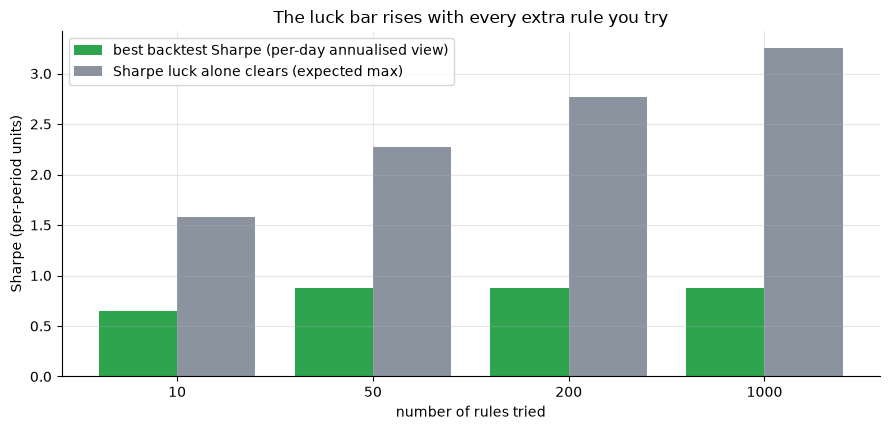

expected-max Sharpe (luck) by N: ['1.57', '2.28', '2.77', '3.26']


In [3]:
ns = [10, 50, 200, 1000]
is_s, sr0s = [], []
for n in ns:
    m = st.sweep(prices, n_trials=n, cost_bps=0.0)
    c = st.in_sample_champion(m, frac=0.5)
    d = st.deflated_sharpe_ratio(m[c['champion']], n_trials=m.shape[1])
    is_s.append(c['is_sharpe']); sr0s.append(d['sr0'])
fig, ax = plt.subplots(figsize=(9, 4.4))
x = range(len(ns))
ax.bar([i-0.2 for i in x], is_s, width=0.4, color=GREEN, label='best backtest Sharpe (per-day annualised view)')
ax.bar([i+0.2 for i in x], [s/np.sqrt(252)*np.sqrt(252) for s in sr0s], width=0.4, color=GREY,
       label='Sharpe luck alone clears (expected max)')
ax.set_xticks(list(x)); ax.set_xticklabels([str(n) for n in ns])
ax.set_xlabel('number of rules tried'); ax.set_ylabel('Sharpe (per-period units)')
ax.set_title('The luck bar rises with every extra rule you try'); ax.legend()
plt.tight_layout(); plt.show()
print('expected-max Sharpe (luck) by N:', [f'{s:.2f}' for s in sr0s])

The grey bar — the Sharpe you'd get **from luck alone** — climbs from ~1.6 at 10 trials to ~3.3 at 1,000. That is why a Sharpe number is meaningless without its trial count. This is the entire engine of the disease, in one chart.

**Third: the catch — does the trap also fool a single honest idea?** No. The tools punish *searching*, not *having an edge*. On a market with a small **real** trend (that you'd earn just by buying and holding), the honest buy-and-hold keeps a clean bill of health — while the grid-searched timing rule is still flagged as overfit.

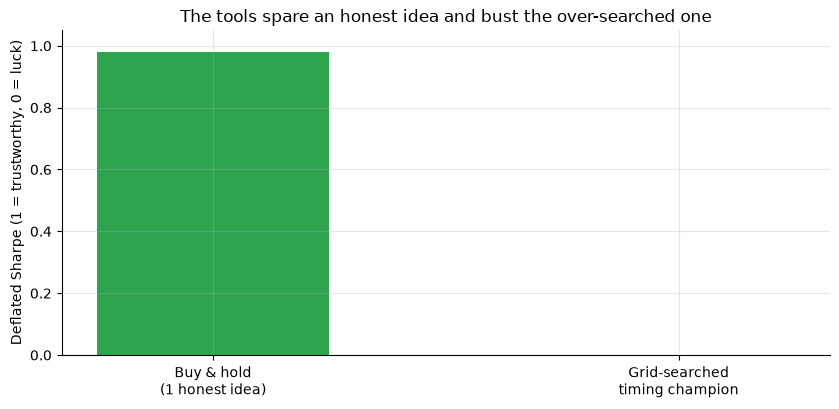

buy-hold DSR 0.98  |  grid-searched champion DSR 0.00


In [4]:
pe, _ = data.synthetic_prices(n_days=ND, edge=0.0003, seed=344)
bh = st.buy_and_hold(pe)
dbh = st.deflated_sharpe_ratio(bh, n_trials=1)
mat_e = st.sweep(pe, n_trials=N_TRIALS, cost_bps=0.0)
ch_e = st.in_sample_champion(mat_e, frac=0.5)
d_e = st.deflated_sharpe_ratio(mat_e[ch_e['champion']], n_trials=mat_e.shape[1])
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(['Buy & hold\n(1 honest idea)', 'Grid-searched\ntiming champion'],
       [dbh['dsr'], d_e['dsr']], color=[GREEN, RED], width=0.5)
ax.set_ylim(0, 1.05); ax.set_ylabel('Deflated Sharpe (1 = trustworthy, 0 = luck)')
ax.set_title('The tools spare an honest idea and bust the over-searched one')
plt.tight_layout(); plt.show()
print(f'buy-hold DSR {dbh["dsr"]:.2f}  |  grid-searched champion DSR {d_e["dsr"]:.2f}')

Buy-and-hold's Deflated Sharpe is **~0.98** (trustworthy) because it was one honest hypothesis, not the survivor of a search. The timing champion — riding the *same* real trend — deflates to **~0**, because its in-sample shine was bought with 1,000 tries. **The trap is in the *selection*, not in whether an edge exists.**

## 5 · The verdict

- **Signal — None.** By design there is no timing edge; the in-sample Sharpe is pure selection luck and deflates to zero. Nothing real to detect.
- **Tradability — Mirage.** A backtest you can't trade — the pretty number is gone the moment you stop peeking.
- **Does grid-searching fake an edge? — Confirmed.** On a market we *know* is empty, a 1,000-rule sweep built a Sharpe-0.88 'strategy' out of nothing; the Deflated Sharpe (~0) and PBO (68%) catch it cold.

## 6 · Could you actually trade it?

There is, deliberately, nothing to trade — that's the whole point. But the *practical* takeaway is huge: before you risk a cent on any backtest (yours or someone else's), ask **two questions**. (1) *How many configurations did you try?* — then deflate the Sharpe for it. (2) *What's the PBO?* — if your in-sample winner is a coin-flip-or-worse out of sample, you don't have a strategy, you have a fitted ghost. Most blow-ups would have been caught by either question. We run the real SPY version of exactly this in the [quants notebook](02_for_the_quants.ipynb) — and even there, where the champion *looked* fine live, the tools still flash red, because it was riding the market, not timing it.

## 7 · Going further 🚪

- **Add costs and slippage** to the sweep and watch even more 'edges' die — overfitting and cost-blindness are the two horsemen of the dead backtest.
- **Walk-forward instead of one split.** Re-optimise on a rolling window and you'll see the champion *change every period* — a tell that it was never stable.
- **Pre-register your hypothesis.** The cleanest defence: decide the rule *before* you touch the data, so there's nothing to deflate.

*Think your favourite backtest is the real thing? Fork this, paste in your strategy's trial returns, and read off its Deflated Sharpe and PBO. If the number survives, you've got something. If it doesn't, you just saved yourself a live experiment.*